<a href="https://colab.research.google.com/github/Amika1118/DSGP_Group_38/blob/Market-Price-Prediction/final_feature_engineering_before_training_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
%cd /content
!git clone https://github.com/Amika1118/DSGP_Group_38.git
%cd DSGP_Group_38

/content
fatal: destination path 'DSGP_Group_38' already exists and is not an empty directory.
/content/DSGP_Group_38


In [23]:
!git checkout Market-Price-Prediction

Already on 'Market-Price-Prediction'
Your branch is up to date with 'origin/Market-Price-Prediction'.


In [24]:
!git config --global user.name "Lasani Layathma"
!git config --global user.email "lasani.20241357@iit.ac.lk"

In [25]:
from getpass import getpass
token = getpass("Enter GitHub token: ")
!git remote set-url origin https://{token}@github.com/Amika1118/DSGP_Group_38.git


Enter GitHub token: ··········


In [26]:
# Identify & Remove Redundant Features

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('/content/historical_data_preprocessed.csv')
df['Start_Date'] = pd.to_datetime(df['Start_Date'])

print(f"Original shape: {df.shape}")
print(f"Original columns: {len(df.columns)}")

Original shape: (7784, 61)
Original columns: 61


In [27]:
# SAFELY REMOVE UNNECESSARY COLUMNS

def safe_drop_columns(df, columns_to_drop):
    """Safely drop columns if they exist"""
    existing_cols = [col for col in columns_to_drop if col in df.columns]
    return df.drop(columns=existing_cols)

# List of columns to potentially remove
columns_to_remove = [
    'End_Date',  # Redundant with Start_Date
    'Month_Year',  # Redundant with Year+Month
    'Days_In_Week',  # Mostly constant
    'Manual_Rolling_Mean_4w',  # If it exists and is duplicate
    'Manual_Rolling_Mean_4w_scaled',  # If it exists
]

# Also remove any Is_* columns that are all the same value
variety_cols = [col for col in df.columns if col.startswith('Is_')]
for col in variety_cols:
    if df[col].nunique() == 1:
        columns_to_remove.append(col)

df = safe_drop_columns(df, columns_to_remove)
print(f" After removing redundant columns: {df.shape}")

 After removing redundant columns: (7784, 56)


In [28]:
# CREATE OPTIMIZED FEATURE SET (FIXED VERSION)

def create_optimized_features_safe(df):
    """Create optimized feature set with safe column checks"""

    # CORE FEATURES - Check each one exists
    possible_core_features = [
        # Lag features
        'Weekly_Price_lag1', 'Weekly_Price_lag2', 'Weekly_Price_lag3',

        # Rolling statistics
        'Rolling_Mean_4w', 'Rolling_Std_4w', 'Rolling_Mean_13w',

        # Price momentum
        'Price_Change_lag1', 'Price_Change_Pct_lag1',

        # External factors
        'Fuel_Price',

        # Temporal features
        'Month_Sin', 'Month_Cos', 'Day_of_Year',

        # Ratios
        'Price_to_Fuel_Ratio', 'Price_to_Rolling_Mean_Ratio',
    ]

    # Keep only features that actually exist
    core_features = [f for f in possible_core_features if f in df.columns]

    print(f" Found {len(core_features)}/{len(possible_core_features)} core features")

    # ENHANCED FEATURES - Check each one exists
    possible_enhanced = [
        'Price_Std', 'Variety_encoded', 'Location_encoded',
        'Season_encoded', 'Quarter_encoded'
    ]
    enhanced_features = [f for f in possible_enhanced if f in df.columns]

    # NEW ENGINEERED FEATURES
    df_opt = df.copy()

    # Check prerequisites before creating new features
    try:
        # 1. Price Acceleration
        if 'Price_Change_lag1' in df_opt.columns and 'Price_Change_lag2' in df_opt.columns:
            df_opt['Price_Acceleration'] = df_opt['Price_Change_lag1'] - df_opt['Price_Change_lag2']
            print(" Created: Price_Acceleration")
    except:
        print("  Could not create Price_Acceleration")

    try:
        # 2. Volatility Regime
        if 'Price_Std' in df_opt.columns:
            df_opt['High_Volatility_Regime'] = (
                df_opt['Price_Std'] > df_opt['Price_Std'].rolling(13, min_periods=1).mean()
            ).astype(int)
            print(" Created: High_Volatility_Regime")
    except:
        print("  Could not create High_Volatility_Regime")

    try:
        # 3. Momentum Indicator
        if 'Price_Change_lag1' in df_opt.columns and 'Price_Change_lag2' in df_opt.columns:
            df_opt['Positive_Momentum'] = (
                (df_opt['Price_Change_lag1'] > 0) &
                (df_opt['Price_Change_lag2'] > 0)
            ).astype(int)
            print(" Created: Positive_Momentum")
    except:
        print("  Could not create Positive_Momentum")

    try:
        # 4. Relative Position in Range
        if 'Weekly_Price' in df_opt.columns and 'Rolling_Mean_4w' in df_opt.columns:
            rolling_min = df_opt['Rolling_Mean_4w'].rolling(4, min_periods=1).min()
            rolling_max = df_opt['Rolling_Mean_4w'].rolling(4, min_periods=1).max()
            df_opt['Price_Position_4w'] = (
                (df_opt['Weekly_Price'] - rolling_min) /
                (rolling_max - rolling_min + 1e-10)
            )
            print(" Created: Price_Position_4w")
    except:
        print("  Could not create Price_Position_4w")

    try:
        # 5. Fuel Impact Ratio
        if 'Price_Change_Pct' in df_opt.columns and 'Fuel_Price' in df_opt.columns:
            df_opt['Fuel_Impact_Ratio'] = df_opt['Price_Change_Pct'] / (df_opt['Fuel_Price'] + 1e-10)
            print(" Created: Fuel_Impact_Ratio")
    except:
        print("  Could not create Fuel_Impact_Ratio")

    try:
        # 6. Trend Consistency
        if 'Price_Change' in df_opt.columns:
            df_opt['Trend_Consistency'] = (
                (df_opt['Price_Change'] > 0).rolling(3, min_periods=1).mean().shift(1)
            )
            print(" Created: Trend_Consistency")
    except:
        print("  Could not create Trend_Consistency")

    # List of newly created features (check if they exist)
    new_features = [
        'Price_Acceleration', 'High_Volatility_Regime', 'Positive_Momentum',
        'Price_Position_4w', 'Fuel_Impact_Ratio', 'Trend_Consistency'
    ]
    existing_new_features = [f for f in new_features if f in df_opt.columns]

    # Combine all features
    all_features = core_features + enhanced_features + existing_new_features

    # Also include some important scaled features if they exist
    scaled_to_consider = [
        'Rolling_Mean_4w_scaled', 'Rolling_Std_4w_scaled',
        'Fuel_Price_scaled'
    ]
    existing_scaled = [f for f in scaled_to_consider if f in df_opt.columns]
    all_features.extend(existing_scaled)

    # Remove duplicates
    all_features = list(dict.fromkeys(all_features))

    # Display summary
    print(f"\n OPTIMIZED FEATURE SET:")
    print(f"   Total features: {len(all_features)}")

    # Categorize features
    categories = {
        'Lag & History': [f for f in all_features if 'lag' in f.lower()],
        'Rolling Stats': [f for f in all_features if 'rolling' in f.lower() or 'mean' in f.lower() or 'std' in f.lower()],
        'Price Dynamics': [f for f in all_features if 'change' in f.lower() or 'acceleration' in f.lower() or 'trend' in f.lower() or 'momentum' in f.lower()],
        'Temporal': [f for f in all_features if 'month' in f.lower() or 'day' in f.lower() or 'year' in f.lower() or 'week' in f.lower() or 'quarter' in f.lower() or 'season' in f.lower()],
        'External Factors': [f for f in all_features if 'fuel' in f.lower() or 'ratio' in f.lower()],
        'Encoded': [f for f in all_features if 'encoded' in f.lower()],
        'New Engineered': existing_new_features,
    }

    for category, features in categories.items():
        if features:
            print(f"\n  {category} ({len(features)}):")
            for feat in features[:10]:  # Show first 10 of each category
                print(f"    • {feat}")
            if len(features) > 10:
                print(f"    • ... and {len(features) - 10} more")

    return df_opt, all_features

# Create optimized features
df_optimized, optimal_features = create_optimized_features_safe(df)

 Found 14/14 core features
 Created: Price_Acceleration
 Created: High_Volatility_Regime
 Created: Positive_Momentum
 Created: Price_Position_4w
 Created: Fuel_Impact_Ratio
 Created: Trend_Consistency

 OPTIMIZED FEATURE SET:
   Total features: 28

  Lag & History (5):
    • Weekly_Price_lag1
    • Weekly_Price_lag2
    • Weekly_Price_lag3
    • Price_Change_lag1
    • Price_Change_Pct_lag1

  Rolling Stats (7):
    • Rolling_Mean_4w
    • Rolling_Std_4w
    • Rolling_Mean_13w
    • Price_to_Rolling_Mean_Ratio
    • Price_Std
    • Rolling_Mean_4w_scaled
    • Rolling_Std_4w_scaled

  Price Dynamics (5):
    • Price_Change_lag1
    • Price_Change_Pct_lag1
    • Price_Acceleration
    • Positive_Momentum
    • Trend_Consistency

  Temporal (8):
    • Weekly_Price_lag1
    • Weekly_Price_lag2
    • Weekly_Price_lag3
    • Month_Sin
    • Month_Cos
    • Day_of_Year
    • Season_encoded
    • Quarter_encoded

  External Factors (6):
    • Fuel_Price
    • Price_to_Fuel_Ratio
    • Price_t

  Filling missing values in: ['Trend_Consistency']

 Training Random Forest on 7784 samples, 28 features...


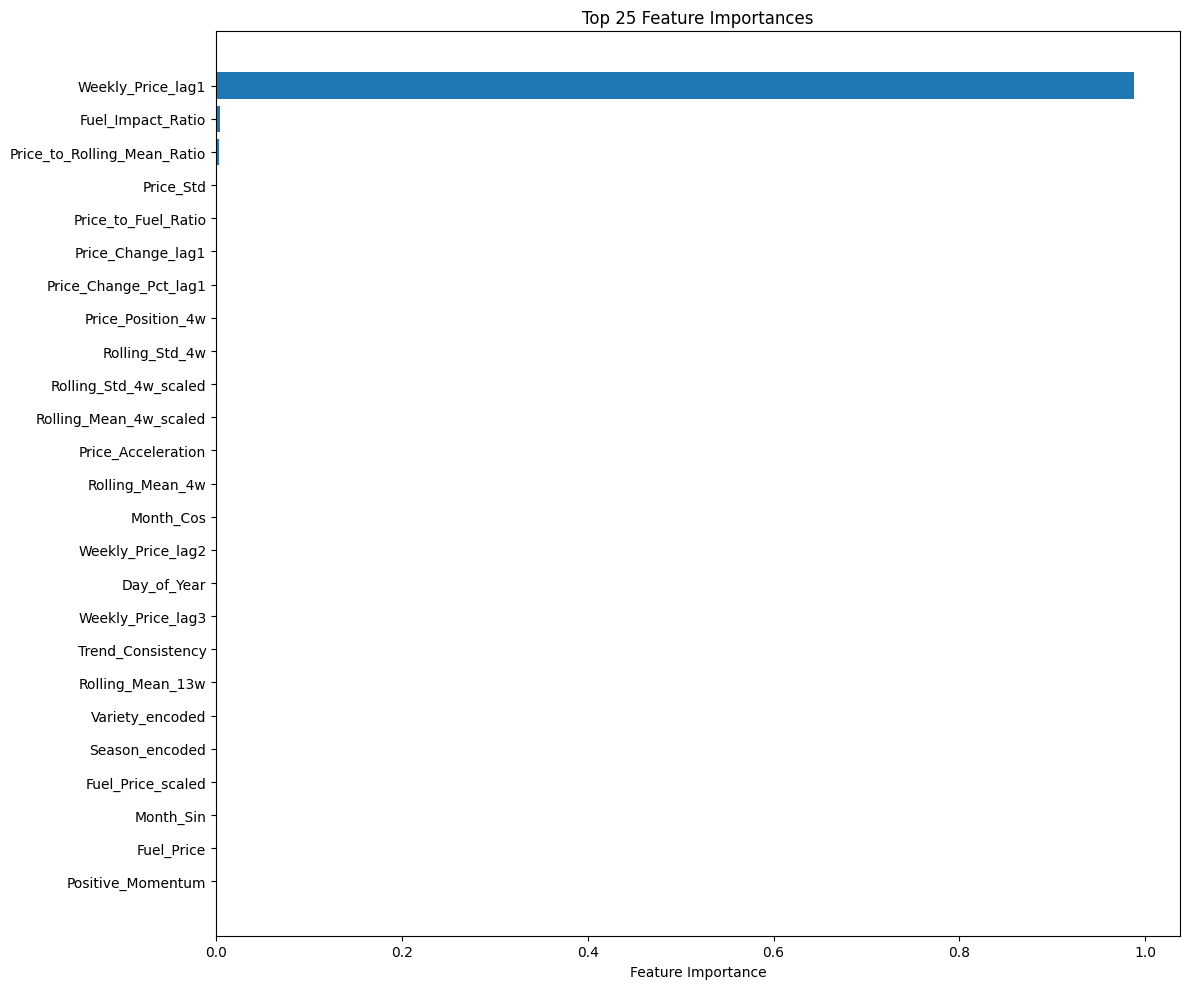


 FEATURE IMPORTANCE SUMMARY:
   Most important feature: Weekly_Price_lag1 (0.988)
   Least important feature: Location_encoded (0.000)

 Low importance features (bottom 30%):
    1. Variety_encoded: 0.00003
    2. Season_encoded: 0.00002
    3. Fuel_Price_scaled: 0.00002
    4. Month_Sin: 0.00002
    5. Fuel_Price: 0.00002
    6. Positive_Momentum: 0.00001
    7. Quarter_encoded: 0.00001
    8. High_Volatility_Regime: 0.00001
    9. Location_encoded: 0.00000


In [30]:
# FEATURE IMPORTANCE ANALYSIS (SAFE VERSION)

def analyze_feature_importance_safe(df, feature_list):
    """Safe feature importance analysis"""

    # Use only historical data for training
    historical_mask = df['Data_Type'] == 'Historical'
    if historical_mask.sum() == 0:
        print("  No historical data found!")
        return None, None

    # Prepare feature matrix
    X = df.loc[historical_mask, feature_list].copy()
    y = df.loc[historical_mask, 'Weekly_Price']

    # Check for missing values
    missing_cols = X.columns[X.isnull().any()].tolist()
    if missing_cols:
        print(f"  Filling missing values in: {missing_cols}")
        X = X.fillna(X.median())

    # Train model
    print(f"\n Training Random Forest on {len(X)} samples, {len(feature_list)} features...")
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': feature_list,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    # Plot top features
    plt.figure(figsize=(12, 10))
    top_n = min(25, len(importance_df))
    top_features = importance_df.head(top_n)

    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Identify low importance features (bottom 30%)
    threshold = importance_df['importance'].quantile(0.3)
    low_importance = importance_df[importance_df['importance'] < threshold]['feature'].tolist()

    print(f"\n FEATURE IMPORTANCE SUMMARY:")
    print(f"   Most important feature: {importance_df.iloc[0]['feature']} ({importance_df.iloc[0]['importance']:.3f})")
    print(f"   Least important feature: {importance_df.iloc[-1]['feature']} ({importance_df.iloc[-1]['importance']:.3f})")

    print(f"\n Low importance features (bottom 30%):")
    for i, feat in enumerate(low_importance[:20], 1):
        importance_val = importance_df[importance_df['feature'] == feat]['importance'].values[0]
        print(f"   {i:2d}. {feat}: {importance_val:.5f}")

    return importance_df, low_importance

# Analyze feature importance
importance_df, low_importance = analyze_feature_importance_safe(df_optimized, optimal_features)

In [31]:
# CREATE FINAL OPTIMIZED DATASET

def create_final_dataset(df, feature_list, remove_low_importance=None):
    """Create final optimized dataset"""

    # Keep only important features
    if remove_low_importance is not None:
        features_to_keep = [f for f in feature_list if f not in remove_low_importance]
        print(f"\nRemoving {len(remove_low_importance)} low-importance features")
    else:
        features_to_keep = feature_list

    # Always keep these metadata columns
    metadata_cols = ['Weekly_Price', 'Start_Date', 'Data_Type']

    # Create final dataset
    final_cols = metadata_cols + features_to_keep
    df_final = df[final_cols].copy()

    # Fill any remaining NaN values
    df_final = df_final.fillna(method='ffill').fillna(method='bfill')

    print(f"\n FINAL DATASET:")
    print(f"   Samples: {len(df_final)}")
    print(f"   Features: {len(features_to_keep)}")
    print(f"   Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

    return df_final

# Option 1: Keep all optimized features
df_final_all = create_final_dataset(df_optimized, optimal_features)

# Option 2: Remove low importance features (recommended)
if low_importance:
    df_final_pruned = create_final_dataset(df_optimized, optimal_features, low_importance)

    # Compare the two options
    print(f"\n COMPARISON:")
    print(f"   Full feature set: {len(optimal_features)} features")
    print(f"   Pruned feature set: {len(optimal_features) - len(low_importance)} features")
    print(f"   Features removed: {len(low_importance)}")

    # Save both versions
    df_final_all.to_csv('retail_prices_full_features.csv', index=False)
    df_final_pruned.to_csv('retail_prices_pruned_features.csv', index=False)

    print(f"\n Saved datasets:")
    print(f"   - retail_prices_full_features.csv ({len(optimal_features)} features)")
    print(f"   - retail_prices_pruned_features.csv ({len(optimal_features) - len(low_importance)} features)")
else:
    df_final_all.to_csv('retail_prices_optimized.csv', index=False)
    print(f" Saved: retail_prices_optimized.csv")

/tmp/ipython-input-1763278963.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-1763278963.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='ffill').fillna(method='bfill')



 FINAL DATASET:
   Samples: 7784
   Features: 28
   Memory usage: 2.2 MB

Removing 9 low-importance features

 FINAL DATASET:
   Samples: 7784
   Features: 19
   Memory usage: 1.7 MB

 COMPARISON:
   Full feature set: 28 features
   Pruned feature set: 19 features
   Features removed: 9

 Saved datasets:
   - retail_prices_full_features.csv (28 features)
   - retail_prices_pruned_features.csv (19 features)


In [32]:
# QUICK MODEL PERFORMANCE CHECK

def quick_performance_check(df_train, df_test, feature_list):
    """Quick check of model performance"""

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    # Prepare data
    X = df_train[feature_list]
    y = df_train['Weekly_Price']

    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    # Train
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Metrics
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    print(f"\n QUICK PERFORMANCE CHECK:")
    print(f"   MAE:  ${mae:.2f}")
    print(f"   RMSE: ${rmse:.2f}")
    print(f"   R²:   {r2:.3f}")
    print(f"   Avg Price: ${y_val.mean():.2f}")
    print(f"   Error %: {(mae / y_val.mean()) * 100:.1f}%")

    return model

# Only run if we have historical data
if 'Data_Type' in df_final_pruned.columns:
    historical_data = df_final_pruned[df_final_pruned['Data_Type'] == 'Historical']
    features_for_model = [f for f in optimal_features if f not in low_importance]

    if len(historical_data) > 100:  # Need enough data
        model = quick_performance_check(historical_data, historical_data, features_for_model)


 QUICK PERFORMANCE CHECK:
   MAE:  $3.12
   RMSE: $7.48
   R²:   0.996
   Avg Price: $148.31
   Error %: 2.1%


In [37]:
# First, let's check what files you're trying to add
print("Checking git status...")
!git status

Checking git status...
On branch Market-Price-Prediction
Your branch and 'origin/Market-Price-Prediction' have diverged,
and have 1 and 3 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

nothing to commit, working tree clean


In [38]:
import shutil
import os

print(" Clean Git Sync Solution")

# 1. Backup your important files
print("\n1. Backing up optimized datasets...")
files_to_backup = [
    'retail_prices_pruned_features.csv',
    'retail_prices_full_features.csv'
]

backup_dir = '/tmp/git_backup'
os.makedirs(backup_dir, exist_ok=True)

for file in files_to_backup:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(backup_dir, file))
        print(f"    {file} backed up")

# 2. Reset to match remote exactly
print("\n2. Resetting to remote state...")
!git fetch origin
!git reset --hard origin/Market-Price-Prediction
!git clean -fd  # Remove any untracked files

# 3. Restore your files
print("\n3. Restoring optimized datasets...")
for file in files_to_backup:
    backup_path = os.path.join(backup_dir, file)
    if os.path.exists(backup_path):
        shutil.copy(backup_path, file)
        print(f"    {file} restored")

# 4. Add and commit
print("\n4. Adding files to git...")
!git add retail_prices_pruned_features.csv retail_prices_full_features.csv

print("\n5. Committing...")
!git commit -m "Add optimized retail price datasets: pruned (19 features) and full (28 features)"

# 5. Push
print("\n6. Pushing to GitHub...")
!git push origin Market-Price-Prediction

print(" Successfully pushed optimized datasets!")
print("\n Files added:")
print("   • retail_prices_pruned_features.csv (19 features)")
print("   • retail_prices_full_features.csv (28 features)")

 Clean Git Sync Solution

1. Backing up optimized datasets...
    retail_prices_pruned_features.csv backed up
    retail_prices_full_features.csv backed up

2. Resetting to remote state...
HEAD is now at 955f054 creating historical dataset preprocessed

3. Restoring optimized datasets...
    retail_prices_pruned_features.csv restored
    retail_prices_full_features.csv restored

4. Adding files to git...

5. Committing...
[Market-Price-Prediction 09e3c7a] Add optimized retail price datasets: pruned (19 features) and full (28 features)
 2 files changed, 15570 insertions(+)
 create mode 100644 retail_prices_full_features.csv
 create mode 100644 retail_prices_pruned_features.csv

6. Pushing to GitHub...
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 982.50 KiB | 3.23 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (